# Flood Prediction Machine Learning Model 

#### Importing Required Libraries.

In [4]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
data = pd.read_csv('../dataset/India.csv')
print(data)

   COUNTRY  YEAR   JAN   FEB   MAR    APR    MAY     JUN     JUL    AUG  \
0    INDIA  1901  28.7  44.7  51.6  160.0  174.7   824.6   743.0  357.5   
1    INDIA  1902   6.7   2.6  57.3   83.9  134.5   390.9  1205.0  315.8   
2    INDIA  1903   3.2  18.6   3.1   83.6  249.7   558.6  1022.5  420.2   
3    INDIA  1904  23.7   3.0  32.2   71.5  235.7  1098.2   725.5  351.8   
4    INDIA  1905   1.2  22.3   9.4  105.9  263.3   850.2   520.5  293.6   
..     ...   ...   ...   ...   ...    ...    ...     ...     ...    ...   
81   INDIA  1982   8.2   7.2  35.8   39.9  221.8   816.4   586.4  471.5   
82   INDIA  1983   2.6  16.1   9.4   38.6  103.8   448.5  1125.2  667.8   
83   INDIA  1984  16.4   3.9  14.2   84.1  196.6   728.5   908.4  341.2   
84   INDIA  1985  14.8  12.8  19.2   50.5  189.1   546.8   635.9  394.6   
85   INDIA  1986  10.1   5.5  16.5   49.5  150.2   680.8   602.6  574.6   

      SEP    OCT    NOV    DEC  ANNUAL RAINFALL FLOODS  
0   197.7  266.9  350.8   48.4           3

In [5]:
data.head()

,COUNTRY,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL RAINFALL,FLOODS
0,INDIA,1901,28.7,44.7,51.6,160.0,174.7,824.6,743.0,357.5,197.7,266.9,350.8,48.4,3248.6,YES
1,INDIA,1902,6.7,2.6,57.3,83.9,134.5,390.9,1205.0,315.8,491.6,358.4,158.3,121.5,3326.6,YES
2,INDIA,1903,3.2,18.6,3.1,83.6,249.7,558.6,1022.5,420.2,341.8,354.1,157.0,59.0,3271.2,YES
3,INDIA,1904,23.7,3.0,32.2,71.5,235.7,1098.2,725.5,351.8,222.7,328.1,33.9,3.3,3129.7,YES
4,INDIA,1905,1.2,22.3,9.4,105.9,263.3,850.2,520.5,293.6,217.2,383.5,74.4,0.2,2741.6,NO


In [6]:
data.tail()

,COUNTRY,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL RAINFALL,FLOODS
81,INDIA,1982,8.2,7.2,35.8,39.9,221.8,816.4,586.4,471.5,208.9,182.5,209.5,64.9,2853.0,YES
82,INDIA,1983,2.6,16.1,9.4,38.6,103.8,448.5,1125.2,667.8,316.2,332.2,125.7,15.3,3201.4,YES
83,INDIA,1984,16.4,3.9,14.2,84.1,196.6,728.5,908.4,341.2,154.6,310.2,74.2,45.3,2877.6,YES
84,INDIA,1985,14.8,12.8,19.2,50.5,189.1,546.8,635.9,394.6,199.3,191.2,52.6,16.2,2322.9,NO
85,INDIA,1986,10.1,5.5,16.5,49.5,150.2,680.8,602.6,574.6,322.8,337.5,178.3,50.6,2979.0,YES


# Finding number of missing values

In [7]:
data.isnull().sum()  # cheaking if any colomns is left empty or not.

COUNTRY            0
YEAR               0
JAN                0
FEB                0
MAR                0
APR                0
MAY                0
JUN                0
JUL                0
AUG                0
SEP                0
OCT                0
NOV                0
DEC                0
ANNUAL RAINFALL    0
FLOODS             0
dtype: int64

# Analyzing the Dataset

In [8]:
print(data.shape)

(86, 16)


In [9]:
data.describe()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL RAINFALL
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,1943.500000,13.904651,12.069767,27.298837,78.333721,181.204651,716.593023,779.850000,433.300000,241.475581,300.231395,152.543023,40.732558,2977.583721
std,24.969982,13.902314,11.357092,18.805872,38.969057,120.870210,177.768355,201.872694,164.535854,94.696121,86.771016,65.792922,29.546018,381.376619
min,1901.000000,0.000000,0.100000,0.600000,12.300000,38.600000,341.000000,167.500000,178.600000,48.400000,135.800000,33.900000,0.100000,2178.600000
25%,1922.250000,2.925000,4.725000,13.975000,50.525000,114.600000,589.350000,656.250000,335.625000,169.900000,237.600000,102.825000,15.425000,2719.375000
50%,1943.500000,10.950000,9.000000,23.550000,73.650000,149.650000,704.200000,774.500000,404.000000,240.250000,302.350000,146.900000,38.500000,2957.400000
75%,1964.750000,18.800000,16.425000,37.500000,99.000000,205.775000,849.800000,894.825000,494.875000,297.100000,356.975000,183.350000,55.375000,3245.475000
max,1986.000000,74.500000,65.900000,79.400000,210.700000,738.800000,1162.200000,1526.500000,1199.200000,491.600000,543.200000,350.800000,135.200000,4226.400000


In [10]:
data.info

<bound method DataFrame.info of    COUNTRY  YEAR   JAN   FEB   MAR    APR    MAY     JUN     JUL    AUG  \
0    INDIA  1901  28.7  44.7  51.6  160.0  174.7   824.6   743.0  357.5   
1    INDIA  1902   6.7   2.6  57.3   83.9  134.5   390.9  1205.0  315.8   
2    INDIA  1903   3.2  18.6   3.1   83.6  249.7   558.6  1022.5  420.2   
3    INDIA  1904  23.7   3.0  32.2   71.5  235.7  1098.2   725.5  351.8   
4    INDIA  1905   1.2  22.3   9.4  105.9  263.3   850.2   520.5  293.6   
..     ...   ...   ...   ...   ...    ...    ...     ...     ...    ...   
81   INDIA  1982   8.2   7.2  35.8   39.9  221.8   816.4   586.4  471.5   
82   INDIA  1983   2.6  16.1   9.4   38.6  103.8   448.5  1125.2  667.8   
83   INDIA  1984  16.4   3.9  14.2   84.1  196.6   728.5   908.4  341.2   
84   INDIA  1985  14.8  12.8  19.2   50.5  189.1   546.8   635.9  394.6   
85   INDIA  1986  10.1   5.5  16.5   49.5  150.2   680.8   602.6  574.6   

      SEP    OCT    NOV    DEC  ANNUAL RAINFALL FLOODS  
0   197.7 

In [11]:
numeric_data = data.drop(columns=['COUNTRY', 'FLOODS'])
print(numeric_data.cov())


                        YEAR         JAN         FEB          MAR  \
YEAR              623.500000  -94.587059  -61.928235  -162.960588   
JAN               -94.587059  193.274331  -10.096446    63.281300   
FEB               -61.928235  -10.096446  128.983546    60.479141   
MAR              -162.960588   63.281300   60.479141   353.660822   
APR              -403.302941   97.726782  123.445267   241.066628   
MAY              -688.868235  177.463625   44.260848   255.605770   
JUN              -265.510588  274.267092  -35.878566   313.087168   
JUL               202.957059  -59.083647 -530.175176  -172.344412   
AUG               305.045882  -81.150706 -255.070000   330.315176   
SEP               167.286471 -343.614356  116.272665   178.463148   
OCT              -174.446471  -49.639912  -21.777510  -189.663140   
NOV              -438.374706  128.023680  220.899198   285.189462   
DEC               -43.877647  -71.554859  -29.725592    69.148862   
ANNUAL RAINFALL -1658.128235  318.

In [12]:
print(numeric_data.corr())


                     YEAR       JAN       FEB       MAR       APR       MAY  \
YEAR             1.000000 -0.272475 -0.218375 -0.347033 -0.414470 -0.228244   
JAN             -0.272475  1.000000 -0.063946  0.242044  0.180388  0.105609   
FEB             -0.218375 -0.063946  1.000000  0.283169  0.278925  0.032243   
MAR             -0.347033  0.242044  0.283169  1.000000  0.328945  0.112450   
APR             -0.414470  0.180388  0.278925  0.328945  1.000000  0.144729   
MAY             -0.228244  0.105609  0.032243  0.112450  0.144729  1.000000   
JUN             -0.059815  0.110977 -0.017771  0.093652  0.099737 -0.139813   
JUL              0.040263 -0.021052 -0.231246 -0.045397 -0.035622 -0.211401   
AUG              0.074248 -0.035477 -0.136500  0.106752  0.000674 -0.116422   
SEP              0.070747 -0.261007  0.108113  0.100213  0.027766  0.218972   
OCT             -0.080514 -0.041150 -0.022099 -0.116229  0.063901  0.192809   
NOV             -0.266838  0.139966  0.295630  0.230

In [13]:
print(numeric_data.corr())


                     YEAR       JAN       FEB       MAR       APR       MAY  \
YEAR             1.000000 -0.272475 -0.218375 -0.347033 -0.414470 -0.228244   
JAN             -0.272475  1.000000 -0.063946  0.242044  0.180388  0.105609   
FEB             -0.218375 -0.063946  1.000000  0.283169  0.278925  0.032243   
MAR             -0.347033  0.242044  0.283169  1.000000  0.328945  0.112450   
APR             -0.414470  0.180388  0.278925  0.328945  1.000000  0.144729   
MAY             -0.228244  0.105609  0.032243  0.112450  0.144729  1.000000   
JUN             -0.059815  0.110977 -0.017771  0.093652  0.099737 -0.139813   
JUL              0.040263 -0.021052 -0.231246 -0.045397 -0.035622 -0.211401   
AUG              0.074248 -0.035477 -0.136500  0.106752  0.000674 -0.116422   
SEP              0.070747 -0.261007  0.108113  0.100213  0.027766  0.218972   
OCT             -0.080514 -0.041150 -0.022099 -0.116229  0.063901  0.192809   
NOV             -0.266838  0.139966  0.295630  0.230

In [30]:
# replacing the yes/no in floods coloumn by 1/0
data['FLOODS'] = data['FLOODS'].replace(['YES','NO'],[1,0])

In [31]:
#Printing the clean data
data.head()

,COUNTRY,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL RAINFALL,FLOODS
0,INDIA,1901,28.7,44.7,51.6,160.0,174.7,824.6,743.0,357.5,197.7,266.9,350.8,48.4,3248.6,1
1,INDIA,1902,6.7,2.6,57.3,83.9,134.5,390.9,1205.0,315.8,491.6,358.4,158.3,121.5,3326.6,1
2,INDIA,1903,3.2,18.6,3.1,83.6,249.7,558.6,1022.5,420.2,341.8,354.1,157.0,59.0,3271.2,1
3,INDIA,1904,23.7,3.0,32.2,71.5,235.7,1098.2,725.5,351.8,222.7,328.1,33.9,3.3,3129.7,1
4,INDIA,1905,1.2,22.3,9.4,105.9,263.3,850.2,520.5,293.6,217.2,383.5,74.4,0.2,2741.6,0


In [32]:
# Seperating the data which we are gonna use for prediction.
x=data.iloc[:,1:14]
x.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
0,1901,28.7,44.7,51.6,160.0,174.7,824.6,743.0,357.5,197.7,266.9,350.8,48.4
1,1902,6.7,2.6,57.3,83.9,134.5,390.9,1205.0,315.8,491.6,358.4,158.3,121.5
2,1903,3.2,18.6,3.1,83.6,249.7,558.6,1022.5,420.2,341.8,354.1,157.0,59.0
3,1904,23.7,3.0,32.2,71.5,235.7,1098.2,725.5,351.8,222.7,328.1,33.9,3.3
4,1905,1.2,22.3,9.4,105.9,263.3,850.2,520.5,293.6,217.2,383.5,74.4,0.2


In [33]:
# Now seperate the flood label from the dataset.
y=data.iloc[:,-1]
y

0     1
1     1
2     1
3     1
4     0
     ..
81    1
82    1
83    1
84    0
85    1
Name: FLOODS, Length: 86, dtype: object

# Plotting the Data


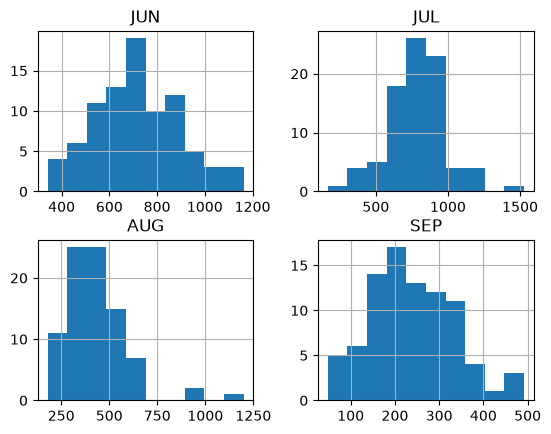

In [34]:
import matplotlib.pyplot as plt   
# sets the backend of matplotlib to the 'inline' backend. 
%matplotlib inline                   
c = data[['JUN','JUL','AUG','SEP']]
c.hist()
plt.show()
# How the rainfall index vary during rainy season

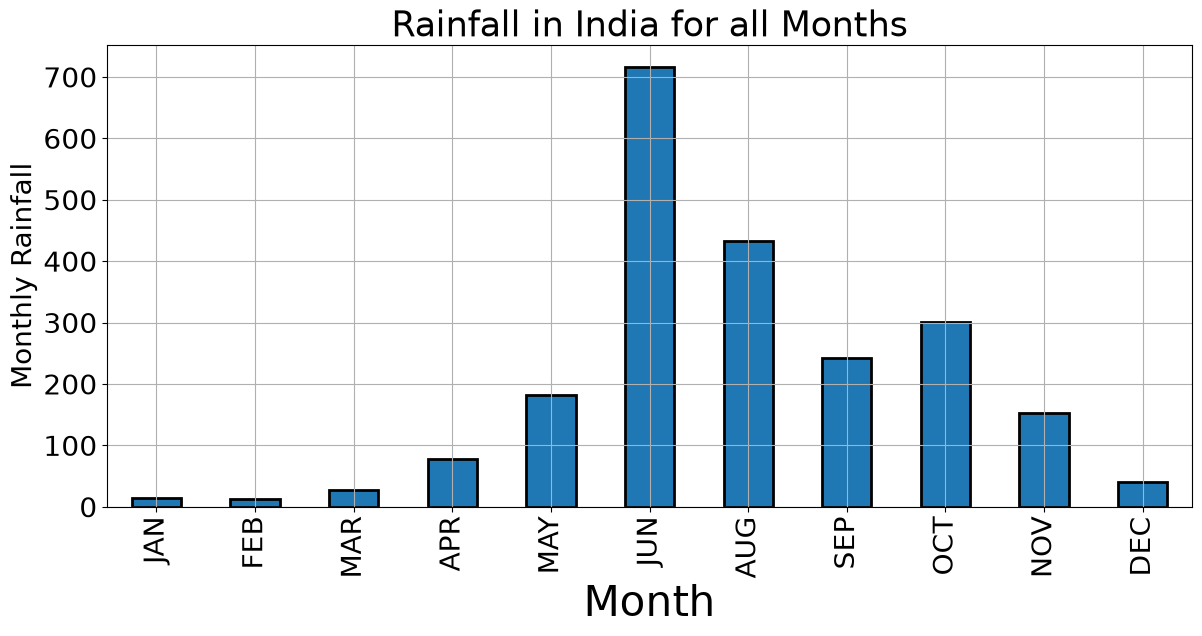

In [35]:
ax = data[['JAN', 'FEB', 'MAR', 'APR','MAY', 'JUN', 'AUG', 'SEP', 'OCT','NOV','DEC']].mean().plot.bar(width=0.5,edgecolor='k',align='center',linewidth=2,figsize=(14,6))
plt.xlabel('Month',fontsize=30)
plt.ylabel('Monthly Rainfall',fontsize=20)
plt.title('Rainfall in India for all Months',fontsize=25)
ax.tick_params(labelsize=20)
plt.grid()
plt.ioff()

# Using sklearn to develop the ML Model

In [36]:
# Scaling the data between 0 and 1.
from sklearn import preprocessing
minmax = preprocessing.MinMaxScaler(feature_range=(0,1))
minmax.fit(x).transform(x)

array([[0.        , 0.3852349 , 0.67781155, ..., 0.32179676, 1.        ,
        0.35751295],
       [0.01176471, 0.08993289, 0.03799392, ..., 0.54639175, 0.39255286,
        0.89859363],
       [0.02352941, 0.04295302, 0.28115502, ..., 0.53583702, 0.38845062,
        0.43597335],
       ...,
       [0.97647059, 0.22013423, 0.05775076, ..., 0.42808051, 0.12716945,
        0.33456699],
       [0.98823529, 0.19865772, 0.19300912, ..., 0.13598429, 0.05900915,
        0.11917098],
       [1.        , 0.13557047, 0.08206687, ..., 0.49509082, 0.45566425,
        0.37379719]], shape=(86, 13))

In [37]:
#dividing the dataset into training dataset and test dataset. 
from sklearn import model_selection,neighbors
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
x_train.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
24,1925,4.1,16.5,76.9,93.4,258.2,688.8,593.5,554.1,158.8,295.4,223.7,98.8
20,1921,43.0,4.7,15.0,171.3,104.1,489.1,639.8,641.9,156.7,302.4,136.2,15.8
49,1950,12.1,1.8,25.8,59.4,236.3,765.5,1233.3,424.8,266.2,364.7,145.3,32.4
41,1942,26.3,4.5,2.8,21.9,38.6,715.5,800.3,424.8,280.6,340.5,150.1,28.4
68,1969,17.7,8.7,12.2,66.1,177.7,695.1,728.2,431.3,264.8,384.6,144.1,64.8


In [38]:
x_train.dtypes

YEAR      int64
JAN     float64
FEB     float64
MAR     float64
APR     float64
MAY     float64
JUN     float64
JUL     float64
AUG     float64
SEP     float64
OCT     float64
NOV     float64
DEC     float64
dtype: object

In [39]:
x_test.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
77,1978,11.1,15.6,32.2,47.9,213.8,496.6,792.2,648.1,264.6,277.1,96.6,13.8
51,1952,11.2,15.9,34.5,136.5,123.6,687.1,825.3,240.3,185.3,237.4,189.6,64.3
18,1919,43.0,6.1,33.9,65.9,247.0,636.8,648.0,484.2,255.9,249.2,280.1,53.0
69,1970,1.1,11.2,26.8,73.6,110.7,594.9,733.6,285.5,367.1,289.4,59.4,25.5
9,1910,2.7,25.7,23.3,124.5,148.8,680.0,484.1,473.8,248.6,356.6,280.4,0.1


In [40]:
# type casting.
y_train=y_train.astype('int')
y_train

24    1
20    0
49    1
41    0
68    1
     ..
44    1
13    0
66    1
70    1
22    1
Name: FLOODS, Length: 68, dtype: int64

In [41]:
y_test=y_test.astype('int')
y_test

77    1
51    1
18    1
69    0
9     0
45    0
58    1
19    1
54    0
32    1
40    0
43    0
80    1
21    1
36    1
0     1
73    0
17    0
Name: FLOODS, dtype: int64

# Using Prediction Algorithms:

## KNN classifier to predict

In [42]:
clf=neighbors.KNeighborsClassifier()
clf.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [43]:
# Predicted chance of Flood.
print("Predicted Values for the Floods:")
y_predict=clf.predict(x_test)
y_predict

Predicted Values for the Floods:


array([1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [44]:
print("Actual Values for the Floods:")
print(y_test)

Actual Values for the Floods:
77    1
51    1
18    1
69    0
9     0
45    0
58    1
19    1
54    0
32    1
40    0
43    0
80    1
21    1
36    1
0     1
73    0
17    0
Name: FLOODS, dtype: int64


In [45]:
print("List of the Predicted Values:")
print(y_predict)

List of the Predicted Values:
[1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1]


In [46]:
# Scaling the dataset.
from sklearn.model_selection import cross_val_score,cross_val_predict
x_train_std= minmax.fit_transform(x_train)
x_test_std= minmax.fit_transform(x_test)
knn_acc=cross_val_score(clf,x_train_std,y_train,cv=3,scoring='accuracy',n_jobs=-1)
knn_proba=cross_val_predict(clf,x_train_std,y_train,cv=3,method='predict_proba')

In [47]:
knn_acc

array([0.65217391, 0.69565217, 0.68181818])

In [48]:
knn_proba

array([[0. , 1. ],
       [0.4, 0.6],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0.4, 0.6],
       [0. , 1. ],
       [0.4, 0.6],
       [0. , 1. ],
       [0. , 1. ],
       [0.2, 0.8],
       [0. , 1. ],
       [0. , 1. ],
       [0.4, 0.6],
       [0. , 1. ],
       [0.2, 0.8],
       [0. , 1. ],
       [0. , 1. ],
       [0.2, 0.8],
       [0.2, 0.8],
       [0. , 1. ],
       [0.6, 0.4],
       [0.6, 0.4],
       [0. , 1. ],
       [0.2, 0.8],
       [0.4, 0.6],
       [0.2, 0.8],
       [0.2, 0.8],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       [0.4, 0.6],
       [0. , 1. ],
       [0.4, 0.6],
       [0.4, 0.6],
       [0. , 1. ],
       [0.4, 0.6],
       [0.2, 0.8],
       [0.2, 0.8],
       [0.2, 0.8],
       [0. , 1. ],
       [0.2, 0.8],
       [0.6, 0.4],
       [0.2, 0.8],
       [0. , 1. ],
       [0.6, 0.4],
       [0. , 1. ],
       [0.4, 0.6],
       [0.2, 0.8],
       [0.4,

### How accurate is our model?

In [49]:
from sklearn.metrics import accuracy_score,recall_score,roc_auc_score,confusion_matrix
print("\nAccuracy Score:%f"%(accuracy_score(y_test,y_predict)*100))
print("Recall Score:%f"%(recall_score(y_test,y_predict)*100))
print("ROC score:%f"%(roc_auc_score(y_test,y_predict)*100))
print(confusion_matrix(y_test,y_predict))


Accuracy Score:66.666667
Recall Score:100.000000
ROC score:62.500000
[[ 2  6]
 [ 0 10]]


## Logistic Regression to predict

In [50]:
x_train_std=minmax.fit_transform(x_train)         # fit the values in between 0 and 1.
y_train_std=minmax.transform(x_test)

from sklearn.model_selection import cross_val_score,cross_val_predict
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)
lr_acc=cross_val_score(lr,x_train_std,y_train,cv=3,scoring='accuracy',n_jobs=-1)
lr_proba=cross_val_predict(lr,x_train_std,y_train,cv=3,method='predict_proba')

/home/ashish-d/.pyenv/versions/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [51]:
lr_acc

array([0.73913043, 0.73913043, 0.72727273])

In [52]:
lr_proba

array([[0.24644411, 0.75355589],
       [0.37747439, 0.62252561],
       [0.15508471, 0.84491529],
       [0.26331935, 0.73668065],
       [0.23287835, 0.76712165],
       [0.14763714, 0.85236286],
       [0.20698943, 0.79301057],
       [0.3149014 , 0.6850986 ],
       [0.20071944, 0.79928056],
       [0.40262475, 0.59737525],
       [0.31329603, 0.68670397],
       [0.11861702, 0.88138298],
       [0.24144358, 0.75855642],
       [0.13381515, 0.86618485],
       [0.26562088, 0.73437912],
       [0.25362477, 0.74637523],
       [0.28500099, 0.71499901],
       [0.22679301, 0.77320699],
       [0.18388781, 0.81611219],
       [0.11312517, 0.88687483],
       [0.28041975, 0.71958025],
       [0.33765336, 0.66234664],
       [0.20518464, 0.79481536],
       [0.30663644, 0.69336356],
       [0.42120698, 0.57879302],
       [0.13773287, 0.86226713],
       [0.3227912 , 0.6772088 ],
       [0.24496126, 0.75503874],
       [0.33242339, 0.66757661],
       [0.23835224, 0.76164776],
       [0.

In [53]:
y_pred=lr.predict(x_test)
y_pred

array([1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [54]:
print(y_test.values)

[1 1 1 0 0 0 1 1 0 1 0 0 1 1 1 1 0 0]


In [55]:
print("List of the Predicted Values:")
print(y_pred)

List of the Predicted Values:
[1 1 1 0 1 0 1 1 0 1 1 1 1 1 1 1 1 1]


### Accuracy and Efficiency of our Model 

In [56]:
from sklearn.metrics import accuracy_score,recall_score,roc_auc_score,confusion_matrix
print("\naccuracy score:%f"%(accuracy_score(y_test,y_pred)*100))
print("recall score:%f"%(recall_score(y_test,y_pred)*100))
print("roc score:%f"%(roc_auc_score(y_test,y_pred)*100))
print(confusion_matrix(y_test,y_pred))


accuracy score:72.222222
recall score:100.000000
roc score:68.750000
[[ 3  5]
 [ 0 10]]


## Support Vector Classification to predict

In [57]:
from sklearn.svm import SVC
svc=SVC(kernel='rbf',probability=True)
svc_classifier=svc.fit(x_train,y_train)
svc_acc=cross_val_score(svc_classifier,x_train_std,y_train,cv=3,scoring="accuracy",n_jobs=-1)
svc_proba=cross_val_predict(svc_classifier,x_train_std,y_train,cv=3,method='predict_proba')

/home/ashish-d/.pyenv/versions/3.12.1/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/ashish-d/.pyenv/versions/3.12.1/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/ashish-d/.pyenv/versions/3.12.1/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/ashish-d/.pyenv/versions/3.12.1/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarn

In [58]:
svc_acc

array([0.73913043, 0.73913043, 0.72727273])

In [59]:
svc_proba

array([[3.51199446e-01, 6.48800554e-01],
       [7.16437108e-01, 2.83562892e-01],
       [8.20634509e-06, 9.99991794e-01],
       [4.24364882e-02, 9.57563512e-01],
       [1.47988302e-02, 9.85201170e-01],
       [9.42204331e-02, 9.05779567e-01],
       [5.12257104e-02, 9.48774290e-01],
       [4.80959795e-01, 5.19040205e-01],
       [7.38255198e-02, 9.26174480e-01],
       [6.95941423e-01, 3.04058577e-01],
       [3.39662754e-01, 6.60337246e-01],
       [2.35521384e-02, 9.76447862e-01],
       [3.81170042e-01, 6.18829958e-01],
       [3.27927355e-01, 6.72072645e-01],
       [9.92801298e-02, 9.00719870e-01],
       [2.54136826e-01, 7.45863174e-01],
       [2.03146826e-01, 7.96853174e-01],
       [2.21143318e-01, 7.78856682e-01],
       [2.46483857e-02, 9.75351614e-01],
       [1.28469535e-02, 9.87153047e-01],
       [2.78547409e-01, 7.21452591e-01],
       [1.46785752e-01, 8.53214248e-01],
       [4.08430145e-02, 9.59156986e-01],
       [5.80901127e-01, 4.19098873e-01],
       [8.400529

In [60]:
svc_scores=svc_proba[:,1]
svc_scores

array([0.64880055, 0.28356289, 0.99999179, 0.95756351, 0.98520117,
       0.90577957, 0.94877429, 0.5190402 , 0.92617448, 0.30405858,
       0.66033725, 0.97644786, 0.61882996, 0.67207265, 0.90071987,
       0.74586317, 0.79685317, 0.77885668, 0.97535161, 0.98715305,
       0.72145259, 0.85321425, 0.95915699, 0.41909887, 0.15994706,
       0.83578848, 0.68150376, 0.76675661, 0.68788285, 0.73799019,
       0.8000666 , 0.74273206, 0.76938326, 0.83320806, 0.73807068,
       0.77647936, 0.70744531, 0.59795924, 0.79401543, 0.73722986,
       0.72150918, 0.79176422, 0.78956616, 0.84740568, 0.75088997,
       0.70605458, 0.75838721, 0.90942576, 0.69347261, 0.7607754 ,
       0.64775908, 0.72382662, 0.65493333, 0.77889947, 0.53588493,
       0.63455918, 0.85563738, 0.84284536, 0.78144918, 0.81327247,
       0.77628729, 0.80934571, 0.69642845, 0.7852563 , 0.69743114,
       0.83338349, 0.84125016, 0.72112497])

In [61]:
y_pred=svc_classifier.predict(x_test)
print("Actual Flood Values:")
print(y_test.values)

Actual Flood Values:
[1 1 1 0 0 0 1 1 0 1 0 0 1 1 1 1 0 0]


In [62]:
print("Predicted Flood Values:")
print(y_pred)

Predicted Flood Values:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


### Accuracy of our model

In [63]:
from sklearn.metrics import accuracy_score,recall_score,roc_auc_score,confusion_matrix
print("\naccuracy score:%f"%(accuracy_score(y_test,y_pred)*100))
print("recall score:%f"%(recall_score(y_test,y_pred)*100))
print("roc score:%f"%(roc_auc_score(y_test,y_pred)*100))
print(confusion_matrix(y_test,y_pred))


accuracy score:55.555556
recall score:100.000000
roc score:50.000000
[[ 0  8]
 [ 0 10]]


# Decision Tree Classification to Predict

In [64]:
from sklearn.tree import DecisionTreeClassifier
dtc_clf=DecisionTreeClassifier()
dtc_clf.fit(x_train,y_train)
dtc_clf_acc=cross_val_score(dtc_clf,x_train_std,y_train,cv=3,scoring="accuracy",n_jobs=-1)
dtc_clf_acc

array([0.69565217, 0.56521739, 0.54545455])

In [65]:
print("Predicted Values:")
y_pred=dtc_clf.predict(x_test)
y_pred

Predicted Values:


array([1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0])

In [66]:
print("Actual Values:")
print(y_test.values)

Actual Values:
[1 1 1 0 0 0 1 1 0 1 0 0 1 1 1 1 0 0]


### Printing the Accuracy

In [67]:
from sklearn.metrics import accuracy_score,recall_score,roc_auc_score,confusion_matrix
print("\naccuracy score:%f"%(accuracy_score(y_test,y_pred)*100))
print("recall score:%f"%(recall_score(y_test,y_pred)*100))
print("roc score:%f"%(roc_auc_score(y_test,y_pred)*100))
print(confusion_matrix(y_test,y_pred))


accuracy score:66.666667
recall score:80.000000
roc score:65.000000
[[4 4]
 [2 8]]


# Random Forest Classifier to predict

In [68]:
from sklearn.ensemble import RandomForestClassifier
rmf=RandomForestClassifier(max_depth=3,random_state=0)
rmf_clf=rmf.fit(x_train,y_train)
rmf_clf

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: 

In [69]:
rmf_clf_acc=cross_val_score(rmf_clf,x_train_std,y_train,cv=3,scoring="accuracy",n_jobs=-1)
rmf_proba=cross_val_predict(rmf_clf,x_train_std,y_train,cv=3,method='predict_proba')

In [70]:
rmf_clf_acc

array([0.73913043, 0.73913043, 0.72727273])

In [71]:
rmf_proba

array([[0.17874035, 0.82125965],
       [0.41515797, 0.58484203],
       [0.05157257, 0.94842743],
       [0.17066803, 0.82933197],
       [0.11408958, 0.88591042],
       [0.19286486, 0.80713514],
       [0.26517502, 0.73482498],
       [0.40839487, 0.59160513],
       [0.07577434, 0.92422566],
       [0.40567774, 0.59432226],
       [0.25446364, 0.74553636],
       [0.08067571, 0.91932429],
       [0.48914477, 0.51085523],
       [0.11465301, 0.88534699],
       [0.26996087, 0.73003913],
       [0.25019676, 0.74980324],
       [0.16233403, 0.83766597],
       [0.29439924, 0.70560076],
       [0.14950658, 0.85049342],
       [0.08537631, 0.91462369],
       [0.38080656, 0.61919344],
       [0.32892338, 0.67107662],
       [0.14481858, 0.85518142],
       [0.2887605 , 0.7112395 ],
       [0.47073102, 0.52926898],
       [0.07293094, 0.92706906],
       [0.4099546 , 0.5900454 ],
       [0.28528115, 0.71471885],
       [0.46942741, 0.53057259],
       [0.27966912, 0.72033088],
       [0.

In [72]:
from sklearn.metrics import accuracy_score,recall_score,roc_auc_score,confusion_matrix
print("\naccuracy score:%f"%(accuracy_score(y_test,y_pred)*100))
print("recall score:%f"%(recall_score(y_test,y_pred)*100))
print("roc score:%f"%(roc_auc_score(y_test,y_pred)*100))
print(confusion_matrix(y_test,y_pred))


accuracy score:66.666667
recall score:80.000000
roc score:65.000000
[[4 4]
 [2 8]]


# Final Accuracy of our Models 

### Comparing all the prediction models

In [73]:
models = []
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
models.append(('KNN', KNeighborsClassifier()))
models.append(('LR', LogisticRegression()))
models.append(('SVC', SVC()))
models.append(('DT', DecisionTreeClassifier()))
models.append(('RF', RandomForestClassifier()))

names = []
scores = []
for name, model in models:
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    scores.append(accuracy_score(y_test, y_pred))
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
tr_split

/home/ashish-d/.pyenv/versions/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Name,Score
0,KNN,0.666667
1,LR,0.722222
2,SVC,0.555556
3,DT,0.777778
4,RF,0.722222


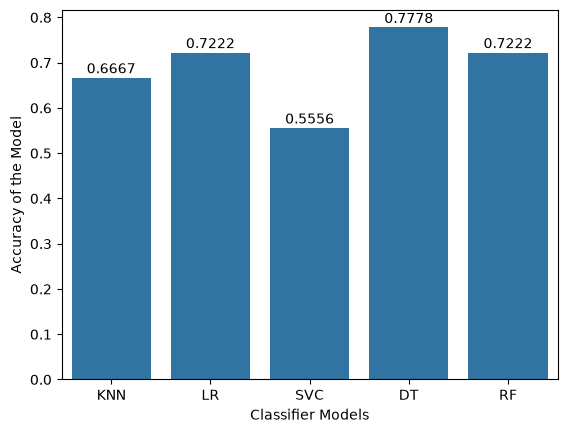

In [74]:
import seaborn as sns
axis = sns.barplot(x = 'Name', y = 'Score', data =tr_split )
axis.set(xlabel='Classifier Models', ylabel='Accuracy of the Model')
for p in axis.patches:
    height = p.get_height()
    axis.text(p.get_x() + p.get_width()/2, height + 0.01, '{:1.4f}'.format(height), ha="center") 
    
plt.show()

In [75]:
tr_split['Score'].max() 

np.float64(0.7777777777777778)

# End of the Code.